Import necessary libraries

In [2]:
import torch
import os
from torch.utils.data import Dataset
from torchvision import datasets
from torch import nn
import torch.nn.functional as F
from torchvision.transforms import ToTensor
import torch.optim as optim
import matplotlib.pyplot as plt

load training & test data

In [3]:
training_data = datasets.MNIST(
    root="data", #location of data
    train=True, #specify is it train or test data
    download=True, #download data if not found in root
    transform=ToTensor() #transform data to tensor
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

classes={
    0:"Zero",
    1:"One",
    2:"Two",
    3:"Three",
    4:"Four",
    5:"Five",
    6:"Six",
    7:"Seven",
    8:"Eight",
    9:"Nine",
}

batch_size=8

train_loader = torch.utils.data.DataLoader(training_data, batch_size=batch_size,shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size,shuffle=True)



100%|██████████| 9.91M/9.91M [00:00<00:00, 18.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 495kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.53MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.61MB/s]


Print some data to ensure data is loaded properly

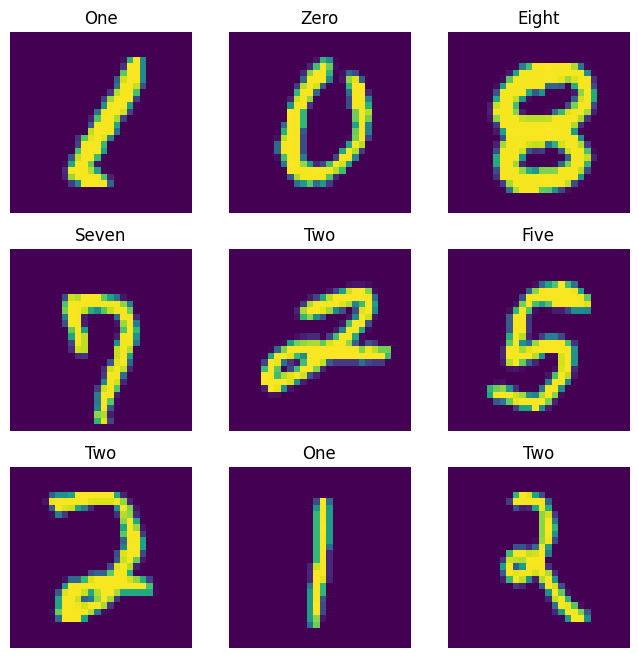

Device used: cuda


In [4]:

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    #load from training data
    if(i>4):
      sample_idx = torch.randint(len(training_data), size=(1,)).item()
      img, label = training_data[sample_idx]
    #load from test data
    else:
      sample_idx = torch.randint(len(test_data), size=(1,)).item()
      img, label = test_data[sample_idx]

    figure.add_subplot(rows, cols, i)
    plt.title(classes[label])
    plt.axis("off")
    plt.imshow(img.squeeze())
plt.show()


device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device used: {device}")

Construct our simple neural network

In [5]:
class MNISTNeuralNetwork(nn.Module):
  def __init__(self):
      super().__init__()
      self.flatten = nn.Flatten()
      self.linear_relu_stack = nn.Sequential(
          nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

  def forward(self,x):
    x=self.flatten(x)
    logits=self.linear_relu_stack(x)
    return logits

net=MNISTNeuralNetwork()
net = net.to(device)
print(net)

MNISTNeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


Define Loss Function & Optimizer


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9)



train the model

In [7]:
epochs_num=5

net.train() #set model to training mode

running_loss = 0.0
for epoch in range(epochs_num):
  for i,(data,label) in enumerate(train_loader):

    data=data.to(device)
    label=label.to(device)

    #zero the parameter gradients
    optimizer.zero_grad()

    #calculate output
    outputs=net(data)

    #calculate loss
    loss=criterion(outputs,label)

    #backprop
    loss.backward()

    #optimize
    optimizer.step()

    # print statistics every 1000
    running_loss += loss.item()
    if i % 1000 == 999:    # print every 2000 mini-batches
        print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 1000:.3f}')
        running_loss = 0.0


print("Training Finished")

[1,  1000] loss: 0.574
[1,  2000] loss: 0.257
[1,  3000] loss: 0.196
[1,  4000] loss: 0.170
[1,  5000] loss: 0.163
[1,  6000] loss: 0.141
[1,  7000] loss: 0.136
[2,  1000] loss: 0.163
[2,  2000] loss: 0.091
[2,  3000] loss: 0.087
[2,  4000] loss: 0.096
[2,  5000] loss: 0.089
[2,  6000] loss: 0.088
[2,  7000] loss: 0.086
[3,  1000] loss: 0.114
[3,  2000] loss: 0.057
[3,  3000] loss: 0.060
[3,  4000] loss: 0.060
[3,  5000] loss: 0.069
[3,  6000] loss: 0.054
[3,  7000] loss: 0.065
[4,  1000] loss: 0.065
[4,  2000] loss: 0.037
[4,  3000] loss: 0.046
[4,  4000] loss: 0.055
[4,  5000] loss: 0.046
[4,  6000] loss: 0.044
[4,  7000] loss: 0.048
[5,  1000] loss: 0.051
[5,  2000] loss: 0.035
[5,  3000] loss: 0.040
[5,  4000] loss: 0.040
[5,  5000] loss: 0.039
[5,  6000] loss: 0.038
[5,  7000] loss: 0.030
Training Finished


Test the network on test data

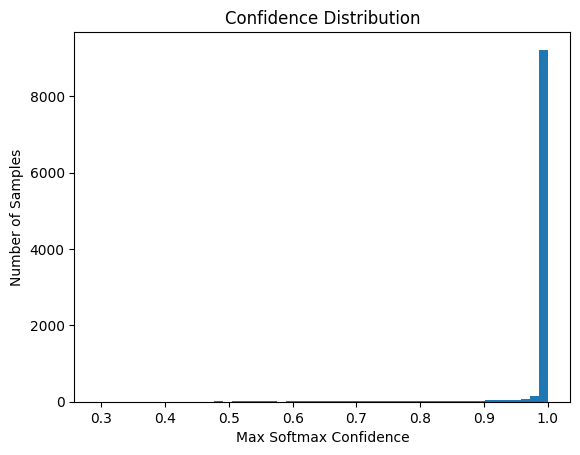

Accuracy on test data: 97.96%


In [10]:
correct=0
total=0
confidence=[]

with torch.no_grad():
  for data,labels in test_loader:
    data=data.to(device)
    labels=labels.to(device)

    output=net(data)
    conf=F.softmax(output,dim=1)
    conf=torch.max(conf,1)[0]
    confidence.extend(conf.cpu().numpy())
    _,predicted_class=torch.max(output,1)
    total+=labels.size(0)
    correct+=(predicted_class==labels).sum().item()


plt.hist(confidence, bins=50)
plt.xlabel('Max Softmax Confidence')
plt.ylabel('Number of Samples')
plt.title('Confidence Distribution')
plt.show()

print(f"Accuracy on test data: {100*correct/total}%")

test model on OOD

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 199kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.78MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.9MB/s]


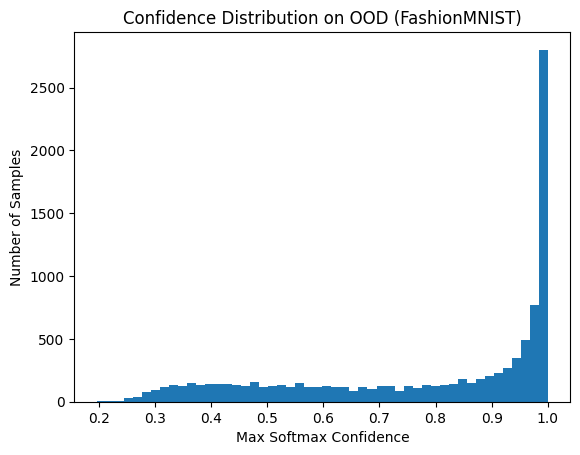

In [9]:
#load data
# correct=0
# total=0

#load OOD dataset
OOD_Test_Data=datasets.FashionMNIST(
    root="data", #location of data
    train=False, #specify is it train or test data
    download=True, #download data if not found in root
    transform=ToTensor() #transform data to tensor
)

# #create test loader
OOD_TEST_Data_Loader=torch.utils.data.DataLoader(OOD_Test_Data, batch_size=batch_size,shuffle=True)

confidences = []

with torch.no_grad():
    for data, labels in OOD_TEST_Data_Loader:
        data = data.to(device)

        outputs = net(data)
        probs = F.softmax(outputs, dim=1)  # Softmax to get probabilities
        max_probs, preds = probs.max(dim=1)  # Get max probability per sample

        confidences.extend(max_probs.cpu().numpy())

# Now we can analyze confidences

plt.hist(confidences, bins=50)
plt.xlabel('Max Softmax Confidence')
plt.ylabel('Number of Samples')
plt.title('Confidence Distribution on OOD (FashionMNIST)')
plt.show()



# with torch.no_grad():
#   for data,labels in OOD_TEST_Data_Loader:
#     data=data.to(device)
#     labels=labels.to(device)

#     output=net(data)
#     _,predicted_class=torch.max(output,1)
#     total+=labels.size(0)
#     correct+=(predicted_class==labels).sum().item()

# print(f"Accuracy on OOD data: {100*correct/total}%")
